# 🧭 Insurance Data EDA for Data Warehousing  
## A Teaching-Grade Notebook for Bronze → Silver Readiness

This notebook performs a **comprehensive Exploratory Data Analysis (EDA)** on messy insurance data across four years.

The purpose is not just to “look at the data.”  
The purpose is to answer this warehouse question:

> **What problems exist in Bronze, and what Silver business rules do we need?**

---

## Dataset

Expected files:

```text
data_messy/insurance.2021.messy.csv
data_messy/insurance.2022.messy.csv
data_messy/insurance.2023.messy.csv
data_messy/insurance.2024.messy.csv
```

Columns:

```text
age, gender, bmi, children, smoker, region, charges
```

---

## Business Rules We Will Validate

| Rule | Business Meaning | Silver Action |
|---|---|---|
| Age validity | Age must be realistic | Reject invalid |
| BMI validity | BMI must be realistic | Reject invalid |
| Charges validity | Charges cannot be negative/missing | Reject invalid |
| Children count | Children must be realistic | Reject invalid |
| Region domain | Keep valid/new regions, standardize messy regions | Standardize / reject |
| Gender/smoker domains | Only approved category values | Standardize / reject |
| Duplicates | Duplicate records inflate metrics | Deduplicate |
| Semantic consistency | Smokers should generally have higher charges | Flag anomalies |

---

## Learning Goals

By the end of this notebook, students should be able to:

1. Perform EDA from a **data warehouse perspective**
2. Identify data quality problems in Bronze
3. Translate EDA findings into Silver business rules
4. Understand why raw data must not flow directly into Gold analytics

## Valid Regions

* southwest	
* southeast	
* northwest	
* northeast	
* south	
* north	
* midwest	


---
# Part 1 — Environment Setup
---

## Cell 01 — Import libraries and connect to DuckDB

### What are we doing?
We import Python libraries and create a DuckDB connection.

### Why?
DuckDB gives us SQL analytics inside Python, which is ideal for teaching warehouse-style EDA.

### DW value
This simulates a small analytical warehouse where we can build Bronze, Silver, and Gold layers.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("insurance_dw_eda_teaching.duckdb")

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.2


## Cell 02 — Define input files

### What are we doing?
We define the four yearly messy CSV files.

### Why?
In real warehouses, data often arrives as partitioned files by year, month, or batch.

### DW value
Tracking file/year lineage helps us debug data quality issues.


In [2]:
files = {
    2021: "data_messy/insurance.2021.messy.csv",
    2022: "data_messy/insurance.2022.messy.csv",
    2023: "data_messy/insurance.2023.messy.csv",
    2024: "data_messy/insurance.2024.messy.csv",
}

files

{2021: 'data_messy/insurance.2021.messy.csv',
 2022: 'data_messy/insurance.2022.messy.csv',
 2023: 'data_messy/insurance.2023.messy.csv',
 2024: 'data_messy/insurance.2024.messy.csv'}

## Cell 03 — Create warehouse schemas

### What are we doing?
We create schemas for the medallion layers.

### Why?
Schemas separate responsibilities:

- `bronze` = raw data
- `silver` = cleaned and validated data
- `gold` = analytics-ready data

### DW value
This creates a professional warehouse organization even for a small teaching dataset.


In [3]:
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")

con.execute("""
SELECT schema_name
FROM information_schema.schemata
WHERE schema_name IN ('bronze', 'silver', 'gold')
ORDER BY schema_name;
""").df()

,schema_name
0,bronze
1,gold
2,silver


---
# Part 2 — Bronze Ingestion
---

## Cell 04 — Load messy files into Bronze

### What are we doing?
We load each messy CSV file into a separate Bronze table.

### Why?
Bronze should preserve raw source values as much as possible.

### DW value
We add technical lineage fields:

- `source_year`
- `source_file`
- `raw_row_id`

These help trace every problem back to the original source.


In [4]:
for year, path in files.items():
    con.execute(f"""
    CREATE OR REPLACE TABLE bronze.insurance_{year}_raw AS
    SELECT
        {year} AS source_year,
        '{path}' AS source_file,
        ROW_NUMBER() OVER () AS raw_row_id,
        *
    FROM read_csv_auto('{path}', header=true, all_varchar=true);
    """)

con.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bronze'
ORDER BY table_name;
""").df()

,table_name
0,insurance_2021_raw
1,insurance_2022_raw
2,insurance_2023_raw
3,insurance_2024_raw


## Cell 05 — Combine yearly Bronze tables

### What are we doing?
We combine all four yearly raw tables into one unified Bronze table.

### Why?
EDA is more powerful when we can compare all years together.

### DW value
This creates a single raw landing table while preserving year-level lineage.


In [5]:
con.execute("""
CREATE OR REPLACE TABLE bronze.insurance_raw AS
SELECT * FROM bronze.insurance_2021_raw
UNION ALL
SELECT * FROM bronze.insurance_2022_raw
UNION ALL
SELECT * FROM bronze.insurance_2023_raw
UNION ALL
SELECT * FROM bronze.insurance_2024_raw;
""")

con.execute("""
SELECT
    source_year,
    COUNT(*) AS bronze_rows
FROM bronze.insurance_raw
GROUP BY source_year
ORDER BY source_year;
""").df()

,source_year,bronze_rows
0,2021,1602
1,2022,1443
2,2023,1615
3,2024,1807


## Cell 06 — Preview Bronze records

### What are we doing?
We inspect a few rows from the raw data.

### Why?
Before writing rules, we need to see what the data actually looks like.

### DW value
This is our first human-readable check of the Bronze layer.


In [6]:
con.execute("""
SELECT *
FROM bronze.insurance_raw
ORDER BY source_year, raw_row_id
LIMIT 12;
""").df()

,source_year,source_file,raw_row_id,age,gender,bmi,children,smoker,region,charges
0,2021,data_messy/insurance.2021.messy.csv,1,42.0,female,40.17,4.0,no,northwest,18902.47
1,2021,data_messy/insurance.2021.messy.csv,2,57.0,female,44.85,1.0,no,northwest,20917.45
2,2021,data_messy/insurance.2021.messy.csv,3,49.0,female,36.38,0.0,no,northeast,18021.33
3,2021,data_messy/insurance.2021.messy.csv,4,47.0,male,31.11,0.0,no,southwest,8580.46
4,2021,data_messy/insurance.2021.messy.csv,5,61.0,female,29.28,1.0,no,southeast,25497.6
5,2021,data_messy/insurance.2021.messy.csv,6,57.0,male,35.91,0.0,yes,north,34998.76
6,2021,data_messy/insurance.2021.messy.csv,7,44.0,female,31.78,4.0,no,northwest,15025.69
7,2021,data_messy/insurance.2021.messy.csv,8,56.0,female,5.0,1.0,no,southwest,23159.42
8,2021,data_messy/insurance.2021.messy.csv,9,49.0,male,15.5,2.0,no,northwest,13653.04
9,2021,data_messy/insurance.2021.messy.csv,10,33.0,female,33.76,2.0,no,southwest,7415.0


---
# Part 3 — Dataset Shape and Volume EDA
---

## Cell 07 — Row counts by year

### What are we doing?
We count rows per source year.

### Why?
Volume changes can indicate either business change or data pipeline problems.

### DW value
This is a basic reconciliation check.


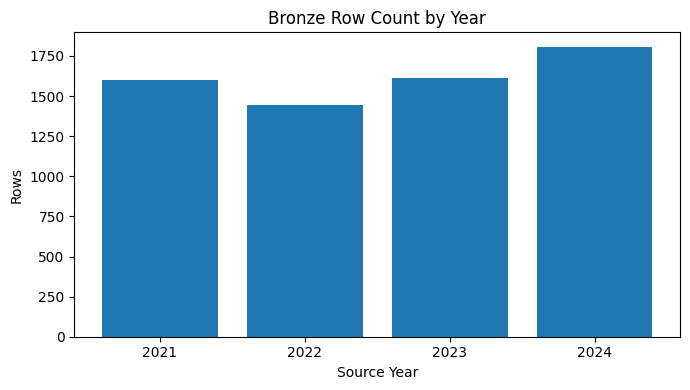

,source_year,row_count
0,2021,1602
1,2022,1443
2,2023,1615
3,2024,1807


In [7]:
df_year_counts = con.execute("""
SELECT
    source_year,
    COUNT(*) AS row_count
FROM bronze.insurance_raw
GROUP BY source_year
ORDER BY source_year;
""").df()

plt.figure(figsize=(7,4))
plt.bar(df_year_counts["source_year"].astype(str), df_year_counts["row_count"])
plt.title("Bronze Row Count by Year")
plt.xlabel("Source Year")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

df_year_counts

### Plot interpretation

Each bar shows how much data arrived for a year.  
If one year is unexpectedly high, duplicate injection or duplicate loading may be present.  
If one year is unexpectedly low, the extract may be incomplete.


## Cell 08 — Schema inspection

### What are we doing?
We inspect the Bronze table columns and data types.

### Why?
Before cleaning, we need to know what DuckDB sees.

### DW value
Schema inspection detects structural drift and confirms ingestion correctness.


In [8]:
con.execute("""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'bronze'
  AND table_name = 'insurance_raw'
ORDER BY ordinal_position;
""").df()

,column_name,data_type
0,source_year,INTEGER
1,source_file,VARCHAR
2,raw_row_id,BIGINT
3,age,VARCHAR
4,gender,VARCHAR
5,bmi,VARCHAR
6,children,VARCHAR
7,smoker,VARCHAR
8,region,VARCHAR
9,charges,VARCHAR


In [9]:
con.execute("""
SELECT
    region,
    count(*) as count
FROM bronze.insurance_raw
GROUP BY region
""").df()

,region,count
0,south west,37
1,southwest,1161
2,north,220
3,NORTHEAST,34
4,mars,40
5,south-west,34
6,moon,37
7,south,413
8,southeast,1537
9,SOUTHWEST,40


---
# Part 4 — Business-Rule-Aligned EDA
---

## Cell 09 — Create typed helper view for EDA

### What are we doing?
We create a typed view that attempts safe casts.

### Why?
Bronze is stored as text. For validation, we need numeric versions of age, BMI, children, and charges.

### DW value
`TRY_CAST` lets us detect unparseable values without crashing the pipeline.


In [10]:
con.execute("""
CREATE OR REPLACE VIEW silver.insurance_profile_view AS
SELECT
    source_year,
    source_file,
    raw_row_id,

    age AS age_raw,
    TRY_CAST(NULLIF(TRIM(age), '') AS INTEGER) AS age_num,

    LOWER(NULLIF(TRIM(gender), '')) AS gender_clean,

    bmi AS bmi_raw,
    TRY_CAST(NULLIF(TRIM(bmi), '') AS DOUBLE) AS bmi_num,

    children AS children_raw,
    TRY_CAST(NULLIF(TRIM(children), '') AS INTEGER) AS children_num,

    LOWER(NULLIF(TRIM(smoker), '')) AS smoker_clean,

    region AS region_raw,
    LOWER(TRIM(region)) AS region_trimmed,
    REPLACE(LOWER(TRIM(region)), ' ', '') AS region_standardized,

    charges AS charges_raw,
    TRY_CAST(NULLIF(TRIM(charges), '') AS DOUBLE) AS charges_num

FROM bronze.insurance_raw;
""")

con.execute("""
SELECT *
FROM silver.insurance_profile_view
LIMIT 10;
""").df()

,source_year,source_file,raw_row_id,age_raw,age_num,gender_clean,bmi_raw,bmi_num,children_raw,children_num,smoker_clean,region_raw,region_trimmed,region_standardized,charges_raw,charges_num
0,2021,data_messy/insurance.2021.messy.csv,1,42.0,42,female,40.17,40.17,4.0,4,no,northwest,northwest,northwest,18902.47,18902.47
1,2021,data_messy/insurance.2021.messy.csv,2,57.0,57,female,44.85,44.85,1.0,1,no,northwest,northwest,northwest,20917.45,20917.45
2,2021,data_messy/insurance.2021.messy.csv,3,49.0,49,female,36.38,36.38,0.0,0,no,northeast,northeast,northeast,18021.33,18021.33
3,2021,data_messy/insurance.2021.messy.csv,4,47.0,47,male,31.11,31.11,0.0,0,no,southwest,southwest,southwest,8580.46,8580.46
4,2021,data_messy/insurance.2021.messy.csv,5,61.0,61,female,29.28,29.28,1.0,1,no,southeast,southeast,southeast,25497.6,25497.60
5,2021,data_messy/insurance.2021.messy.csv,6,57.0,57,male,35.91,35.91,0.0,0,yes,north,north,north,34998.76,34998.76
6,2021,data_messy/insurance.2021.messy.csv,7,44.0,44,female,31.78,31.78,4.0,4,no,northwest,northwest,northwest,15025.69,15025.69
7,2021,data_messy/insurance.2021.messy.csv,8,56.0,56,female,5.0,5.00,1.0,1,no,southwest,southwest,southwest,23159.42,23159.42
8,2021,data_messy/insurance.2021.messy.csv,9,49.0,49,male,15.5,15.50,2.0,2,no,northwest,northwest,northwest,13653.04,13653.04
9,2021,data_messy/insurance.2021.messy.csv,10,33.0,33,female,33.76,33.76,2.0,2,no,southwest,southwest,southwest,7415.0,7415.00


## Cell 10 — Rule summary dashboard

### What are we doing?
We compute all major rule violations in one table.

### Why?
This gives a high-level picture of dataset health.

### DW value
This is the EDA equivalent of a data quality scorecard.


In [11]:
# DEFINE VALID Regions
con.execute("""
CREATE OR REPLACE TABLE silver.dim_valid_region AS
SELECT * FROM (VALUES
    ('northeast'),
    ('northwest'),
    ('southeast'),
    ('southwest'),
    ('midwest'),
    ('north'),
    ('south')
) AS t(region);
""")

con.execute("""
SELECT * 
FROM silver.dim_valid_region
""").df()

,region
0,northeast
1,northwest
2,southeast
3,southwest
4,midwest
5,north
6,south


In [12]:
df_rule_summary = con.execute("""
WITH duplicate_groups AS (
    SELECT
        age_raw, gender_clean, bmi_raw, children_raw, smoker_clean, region_raw, charges_raw,
        COUNT(*) AS cnt
    FROM silver.insurance_profile_view
    GROUP BY age_raw, gender_clean, bmi_raw, children_raw, smoker_clean, region_raw, charges_raw
    HAVING COUNT(*) > 1
)
SELECT 'invalid_age' AS rule_check,
       COUNT(*) AS issue_count
FROM silver.insurance_profile_view
WHERE age_num IS NULL OR age_num < 0 OR age_num > 120

UNION ALL
SELECT 'invalid_bmi',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE bmi_num IS NULL OR bmi_num < 10 OR bmi_num > 60

UNION ALL
SELECT 'invalid_charges',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE charges_num IS NULL OR charges_num < 0

UNION ALL
SELECT 'invalid_children',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE children_num IS NULL OR children_num < 0 OR children_num > 10

UNION ALL
SELECT 'invalid_gender',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE gender_clean NOT IN ('male', 'female')

UNION ALL
SELECT 'invalid_smoker',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE smoker_clean NOT IN ('yes', 'no')

UNION ALL

SELECT 'invalid_region_after_standardization' AS rule,
       COUNT(*)
FROM silver.insurance_profile_view p
LEFT JOIN silver.dim_valid_region v
    ON p.region_standardized = v.region
WHERE v.region IS NULL


UNION ALL
SELECT 'extra_duplicate_rows',
       COALESCE(SUM(cnt - 1), 0)
FROM duplicate_groups

UNION ALL
SELECT 'semantic_smoker_low_charge_flags',
       COUNT(*)
FROM silver.insurance_profile_view
WHERE smoker_clean = 'yes'
  AND charges_num IS NOT NULL
  AND charges_num < 500;
""").df()

df_rule_summary

,rule_check,issue_count
0,invalid_age,329.0
1,invalid_bmi,307.0
2,invalid_charges,307.0
3,invalid_children,349.0
4,invalid_gender,151.0
5,invalid_smoker,165.0
6,invalid_region_after_standardization,196.0
7,extra_duplicate_rows,287.0
8,semantic_smoker_low_charge_flags,30.0


## Cell 11 — Plot rule violations

### What are we doing?
We visualize the rule summary.

### Why?
A chart makes it clear which rules create the most issues.

### DW value
This helps prioritize Silver-layer cleaning work.


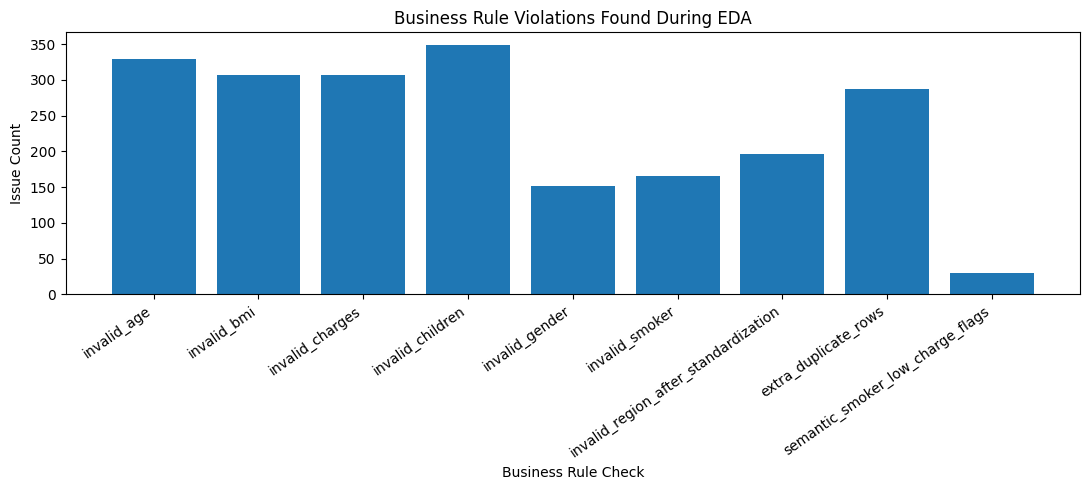

In [13]:
plt.figure(figsize=(11,5))
plt.bar(df_rule_summary["rule_check"], df_rule_summary["issue_count"])
plt.title("Business Rule Violations Found During EDA")
plt.xlabel("Business Rule Check")
plt.ylabel("Issue Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

The tallest bars show which issues are most common.  
Those rules deserve special attention in Silver because they affect many records.


---
# Part 5 — Rule-by-Rule Deep Dive
---

## Cell 12 — Rule 1: Age validity

### Business rule
Age must be between **0 and 120**.

### What are we doing?
We find records where age is missing, not numeric, negative, or unrealistically high.

### Why?
Age is a core risk factor in insurance.

### DW value
Invalid ages should not flow into Gold analytics.


In [14]:
con.execute("""
SELECT
    source_year,
    raw_row_id,
    age_raw,
    age_num,
    gender_clean,
    smoker_clean,
    charges_raw
FROM silver.insurance_profile_view
WHERE age_num IS NULL OR age_num < 0 OR age_num > 120
ORDER BY source_year, raw_row_id
LIMIT 25;
""").df()

,source_year,raw_row_id,age_raw,age_num,gender_clean,smoker_clean,charges_raw
0,2021,33,None,<NA>,male,no,1394.02
1,2021,65,-10.0,-10,female,yes,42448.66
2,2021,106,150.0,150,male,no,14100.98
3,2021,130,150.0,150,male,no,1714.25
4,2021,164,-10.0,-10,female,yes,33474.9
5,2021,177,None,<NA>,female,None,28103.71
6,2021,190,None,<NA>,female,no,15077.17
7,2021,201,-10.0,-10,None,no,22372.1
8,2021,216,-10.0,-10,None,yes,44705.97
9,2021,235,150.0,150,male,yes,41271.48


## Cell 13 — Age distribution

### What are we doing?
We plot the valid age distribution.

### Why?
This helps us understand the population profile.

### DW value
This supports Gold-level age grouping and segmentation.


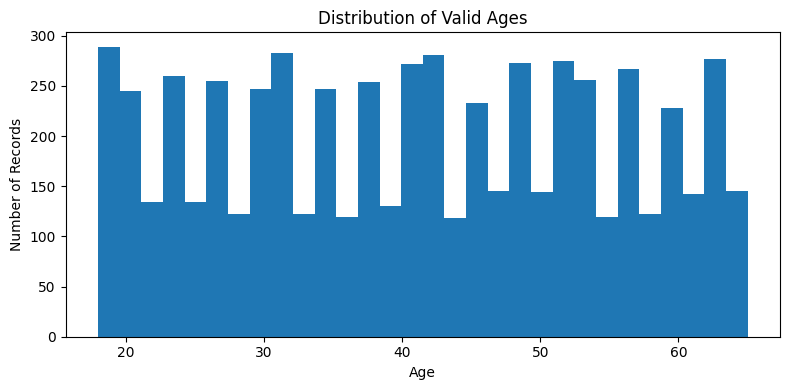

In [15]:
df_age = con.execute("""
SELECT age_num AS age
FROM silver.insurance_profile_view
WHERE age_num BETWEEN 0 AND 120;
""").df()

plt.figure(figsize=(8,4))
plt.hist(df_age["age"], bins=30)
plt.title("Distribution of Valid Ages")
plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Cell 14 — Rule 2: BMI validity

### Business rule
BMI must be between **10 and 60**.

### What are we doing?
We identify BMI values that are missing, not numeric, or outside a realistic human range.

### Why?
BMI is a health risk variable.

### DW value
Invalid BMI values distort segmentation and risk analysis.


In [16]:
con.execute("""
SELECT
    source_year,
    raw_row_id,
    bmi_raw,
    bmi_num,
    age_num,
    smoker_clean,
    charges_num
FROM silver.insurance_profile_view
WHERE bmi_num IS NULL OR bmi_num < 10 OR bmi_num > 60
ORDER BY source_year, raw_row_id
LIMIT 25;
""").df()

,source_year,raw_row_id,bmi_raw,bmi_num,age_num,smoker_clean,charges_num
0,2021,8,5.0,5.0,56,no,23159.42
1,2021,19,5.0,5.0,63,no,25581.04
2,2021,34,None,NaN,24,yes,27011.04
3,2021,48,80.0,80.0,60,no,23759.67
4,2021,53,80.0,80.0,37,no,NaN
5,2021,90,5.0,5.0,57,no,NaN
6,2021,110,5.0,5.0,50,no,14778.89
7,2021,125,5.0,5.0,60,no,21586.92
8,2021,130,80.0,80.0,150,no,1714.25
9,2021,131,5.0,5.0,61,None,29066.59


## Cell 15 — BMI distribution

### What are we doing?
We plot valid BMI values.

### Why?
This reveals the shape of BMI distribution and possible outliers.

### DW value
This helps decide BMI group thresholds in Silver/Gold.


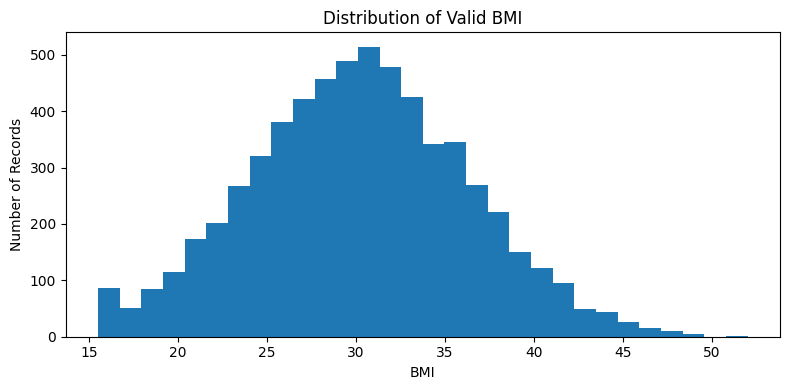

In [17]:
df_bmi = con.execute("""
SELECT bmi_num AS bmi
FROM silver.insurance_profile_view
WHERE bmi_num BETWEEN 10 AND 60;
""").df()

plt.figure(figsize=(8,4))
plt.hist(df_bmi["bmi"], bins=30)
plt.title("Distribution of Valid BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Cell 16 — Rule 3: Charges validity

### Business rule
Charges must be non-negative and numeric.

### What are we doing?
We detect missing, non-numeric, and negative charges.

### Why?
Charges are the primary financial measure.

### DW value
Bad charges directly corrupt Gold KPIs such as average charges and total charges.


In [18]:
con.execute("""
SELECT
    source_year,
    raw_row_id,
    charges_raw,
    charges_num,
    age_num,
    bmi_num,
    smoker_clean
FROM silver.insurance_profile_view
WHERE charges_num IS NULL OR charges_num < 0
ORDER BY source_year, raw_row_id
LIMIT 25;
""").df()

,source_year,raw_row_id,charges_raw,charges_num,age_num,bmi_num,smoker_clean
0,2021,24,None,NaN,32,30.58,no
1,2021,43,None,NaN,33,30.48,no
2,2021,50,-100.0,-100.0,35,24.88,yes
3,2021,53,None,NaN,37,80.00,no
4,2021,54,None,NaN,25,27.96,None
5,2021,90,None,NaN,57,5.00,no
6,2021,92,None,NaN,63,15.97,yes
7,2021,99,-100.0,-100.0,18,31.14,None
8,2021,109,None,NaN,42,31.75,no
9,2021,132,-100.0,-100.0,23,24.38,no


## Cell 17 — Charges distribution

### What are we doing?
We plot valid charges.

### Why?
Insurance charges are usually skewed and may contain high-cost outliers.

### DW value
This helps determine whether averages, medians, or percentiles are better Gold KPIs.


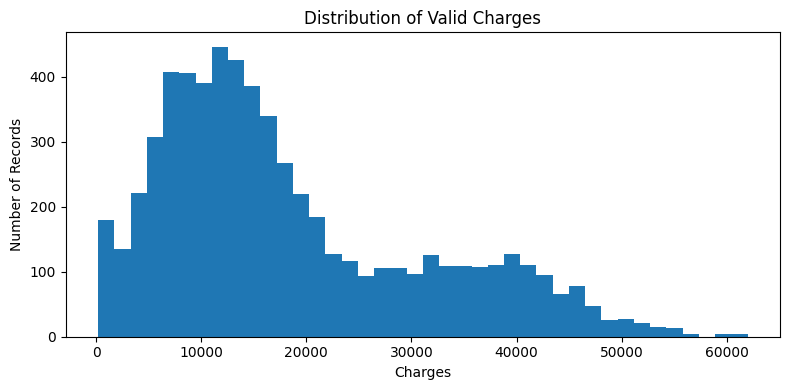

In [19]:
df_charges = con.execute("""
SELECT charges_num AS charges
FROM silver.insurance_profile_view
WHERE charges_num >= 0;
""").df()

plt.figure(figsize=(8,4))
plt.hist(df_charges["charges"], bins=40)
plt.title("Distribution of Valid Charges")
plt.xlabel("Charges")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Cell 18 — Rule 4: Children count validity

### Business rule
Children must be between **0 and 10**.

### What are we doing?
We detect unrealistic or invalid children counts.

### Why?
Children count is used in insurance pricing and family coverage analysis.

### DW value
Invalid values distort segmentation and pricing analysis.


In [20]:
con.execute("""
SELECT
    source_year,
    raw_row_id,
    children_raw,
    children_num,
    age_num,
    charges_num
FROM silver.insurance_profile_view
WHERE children_num IS NULL OR children_num < 0 OR children_num > 10
ORDER BY source_year, raw_row_id
LIMIT 25;
""").df()

,source_year,raw_row_id,children_raw,children_num,age_num,charges_num
0,2021,39,15.0,15,59,34377.09
1,2021,54,None,<NA>,25,NaN
2,2021,62,None,<NA>,60,36558.21
3,2021,64,None,<NA>,47,7347.10
4,2021,72,15.0,15,29,4228.90
5,2021,73,-2.0,-2,56,7407.79
6,2021,74,-2.0,-2,19,200.00
7,2021,110,-2.0,-2,50,14778.89
8,2021,114,None,<NA>,19,33825.87
9,2021,131,None,<NA>,61,29066.59


## Cell 19 — Children distribution

### What are we doing?
We show valid children counts.

### Why?
This is a discrete variable, so a bar chart is appropriate.

### DW value
This helps build family-size segmentation.


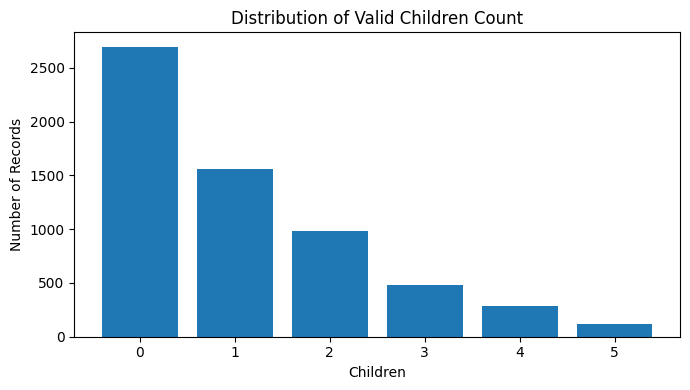

,children,row_count
0,0,2695
1,1,1560
2,2,983
3,3,481
4,4,282
5,5,117


In [21]:
df_children = con.execute("""
SELECT
    children_num AS children,
    COUNT(*) AS row_count
FROM silver.insurance_profile_view
WHERE children_num BETWEEN 0 AND 10
GROUP BY children_num
ORDER BY children_num;
""").df()

plt.figure(figsize=(7,4))
plt.bar(df_children["children"].astype(str), df_children["row_count"])
plt.title("Distribution of Valid Children Count")
plt.xlabel("Children")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

df_children

## Cell 20 — Rule 5: Region standardization

### Business rule
Valid regions are:

```text
northeast, northwest, southeast, southwest, midwest, north, south
```

But formatting issues such as `north east` and `south west` should be standardized, not rejected.

### What are we doing?
We compare raw region values with standardized region values.

### Why?
This teaches the difference between **messy formatting** and **invalid business values**.

### DW value
Proper standardization prevents false categories in dashboards.


In [22]:
con.execute("""
SELECT
    region_raw,
    region_trimmed,
    region_standardized,
    COUNT(*) AS row_count
FROM silver.insurance_profile_view
GROUP BY region_raw, region_trimmed, region_standardized
ORDER BY row_count DESC, region_raw
LIMIT 50;
""").df()

,region_raw,region_trimmed,region_standardized,row_count
0,southeast,southeast,southeast,1537
1,northwest,northwest,northwest,1328
2,northeast,northeast,northeast,1181
3,southwest,southwest,southwest,1161
4,south,south,south,413
5,midwest,midwest,midwest,293
6,north,north,north,220
7,unknown,unknown,unknown,43
8,north-east,north-east,north-east,42
9,SOUTHWEST,southwest,southwest,40


## Cell 21 — Region before vs after standardization

### What are we doing?
We compare distinct raw regions to distinct standardized valid regions.

### Why?
This shows how Silver cleaning reduces category chaos.

### DW value
Cleaner categories create more reliable dimension tables and dashboards.


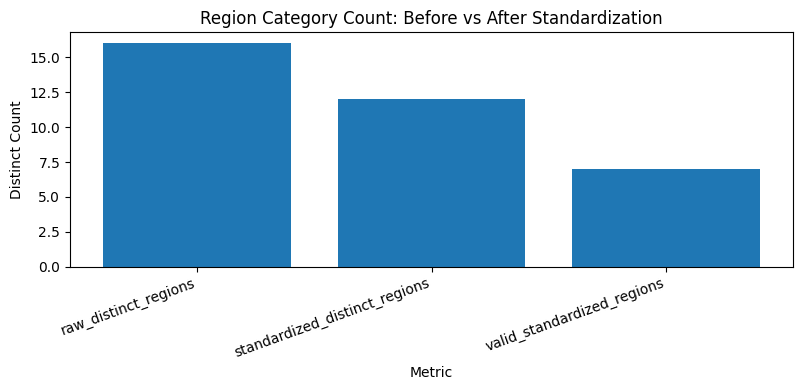

,metric,value
0,raw_distinct_regions,16
1,standardized_distinct_regions,12
2,valid_standardized_regions,7


In [23]:
df_region_compare = con.execute("""
SELECT 'raw_distinct_regions' AS metric, COUNT(DISTINCT region_raw) AS value
FROM silver.insurance_profile_view
UNION ALL
SELECT 'standardized_distinct_regions',
       COUNT(DISTINCT region_standardized)
FROM silver.insurance_profile_view
UNION ALL
SELECT 'valid_standardized_regions',
       COUNT(DISTINCT region_standardized)
FROM silver.insurance_profile_view
WHERE region_standardized IN (
    'northeast','northwest','southeast','southwest',
    'midwest','north','south'
);
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_region_compare["metric"], df_region_compare["value"])
plt.title("Region Category Count: Before vs After Standardization")
plt.xlabel("Metric")
plt.ylabel("Distinct Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_region_compare

### Plot interpretation

If raw regions have many distinct forms but standardized regions collapse to fewer categories, Silver cleaning is successfully reducing noise while preserving valid business meaning.


## Cell 22 — Invalid regions after standardization

### What are we doing?
We find regions that remain invalid even after trimming, lowercasing, and removing spaces.

### Why?
Values like `mars` are not formatting issues; they are invalid business values.

### DW value
These records should be rejected or flagged in Silver.


In [24]:
con.execute("""

WITH cleaned AS (

    SELECT

        region_raw,

        -- 🔧 full standardization

        REPLACE(

            REPLACE(LOWER(TRIM(region_raw)), ' ', ''),

            '-', ''

        ) AS region_standardized

    FROM silver.insurance_profile_view

)

SELECT

    c.region_raw,

    c.region_standardized,

    COUNT(*) AS row_count

FROM cleaned c

LEFT JOIN silver.dim_valid_region v

    ON c.region_standardized = v.region

-- ❌ keep only invalid regions

WHERE v.region IS NULL

GROUP BY

    c.region_raw,

    c.region_standardized

ORDER BY row_count DESC;

""").df()

,region_raw,region_standardized,row_count
0,unknown,unknown,43
1,mars,mars,40
2,moon,moon,37


## Cell 23 — Rule 6: Gender and smoker domain integrity

### Business rule
- gender must be `male` or `female`
- smoker must be `yes` or `no`

### What are we doing?
We inspect category values and invalid counts.

### Why?
These fields are important dimensions for insurance analysis.

### DW value
Invalid categories create incorrect groups in Gold dashboards.


In [25]:
print("Gender profile:")
display(con.execute("""
SELECT
    gender_clean,
    COUNT(*) AS row_count
FROM silver.insurance_profile_view
GROUP BY gender_clean
ORDER BY row_count DESC;
""").df())

print("Smoker profile:")
display(con.execute("""
SELECT
    smoker_clean,
    COUNT(*) AS row_count
FROM silver.insurance_profile_view
GROUP BY smoker_clean
ORDER BY row_count DESC;
""").df())

Gender profile:


,gender_clean,row_count
0,male,3191
1,female,2955
2,None,170
3,m,83
4,unknown,68


Smoker profile:


,smoker_clean,row_count
0,no,4600
1,yes,1520
2,None,182
3,occasionally,83
4,maybe,82


## Cell 24 — Rule 7: Duplicate records

### Business rule
Duplicate rows should not exist.

### What are we doing?
We find duplicate groups and extra duplicate rows.

### Why?
Duplicates inflate row counts and distort averages.

### DW value
Deduplication is a core Silver-layer responsibility.


In [26]:
con.execute("""
WITH duplicate_groups AS (
    SELECT
        age_raw, gender_clean, bmi_raw, children_raw, smoker_clean, region_raw, charges_raw,
        COUNT(*) AS cnt
    FROM silver.insurance_profile_view
    GROUP BY age_raw, gender_clean, bmi_raw, children_raw, smoker_clean, region_raw, charges_raw
    HAVING COUNT(*) > 1
)
SELECT
    COUNT(*) AS duplicate_groups,
    COALESCE(SUM(cnt - 1), 0) AS extra_duplicate_rows
FROM duplicate_groups;
""").df()

,duplicate_groups,extra_duplicate_rows
0,287,287.0


## Cell 25 — Example duplicate groups

### What are we doing?
We show examples of duplicate values.

### Why?
Students should see what duplicate records look like.

### DW value
This supports the decision to deduplicate in Silver.


In [27]:
con.execute("""
SELECT
    age_raw,
    gender_clean,
    bmi_raw,
    children_raw,
    smoker_clean,
    region_raw,
    charges_raw,
    COUNT(*) AS duplicate_count
FROM silver.insurance_profile_view
GROUP BY age_raw, gender_clean, bmi_raw, children_raw, smoker_clean, region_raw, charges_raw
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
LIMIT 20;
""").df()

,age_raw,gender_clean,bmi_raw,children_raw,smoker_clean,region_raw,charges_raw,duplicate_count
0,31.0,male,26.66,0.0,no,northeast,9601.14,2
1,26.0,male,45.03,3.0,no,southeast,20787.64,2
2,23.0,male,25.03,0.0,yes,north,26842.4,2
3,62.0,male,29.31,1.0,no,northwest,18975.9,2
4,62.0,female,39.34,1.0,no,southeast,27344.98,2
5,-10.0,male,80.0,0.0,occasionally,southwest,36923.33,2
6,29.0,male,48.33,0.0,no,southwest,18437.67,2
7,64.0,None,38.14,0.0,no,northwest,20673.21,2
8,28.0,male,36.6,-2.0,no,northwest,11198.02,2
9,53.0,female,16.52,-2.0,no,northeast,5687.09,2


## Cell 26 — Rule 8: Semantic consistency

### Business rule
Smokers generally should have higher charges than non-smokers.

### What are we doing?
We compare average charges by smoker status and flag unusually low smoker charges.

### Why?
Some issues are not invalid by type or domain, but suspicious by business meaning.

### DW value
Semantic anomalies may be flagged rather than rejected.


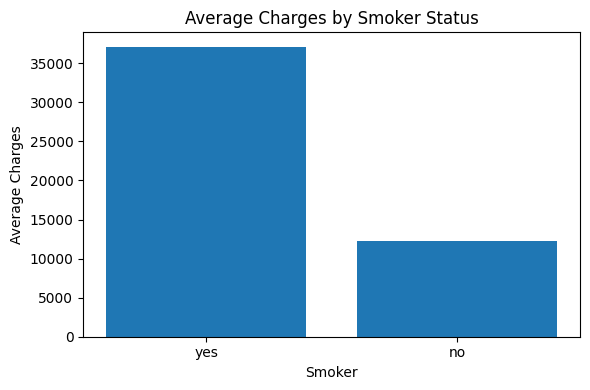

,smoker,row_count,avg_charges,median_charges
0,yes,1465,37107.14,37061.53
1,no,4396,12253.41,11906.94


In [28]:
df_smoker = con.execute("""
SELECT
    smoker_clean AS smoker,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges,
    ROUND(quantile_cont(charges_num, 0.50), 2) AS median_charges
FROM silver.insurance_profile_view
WHERE charges_num IS NOT NULL
  AND charges_num >= 0
  AND smoker_clean IN ('yes', 'no')
GROUP BY smoker_clean
ORDER BY avg_charges DESC;
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_smoker["smoker"], df_smoker["avg_charges"])
plt.title("Average Charges by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

df_smoker

### Plot interpretation

If smokers have much higher average charges, this confirms the expected business relationship.  
Very low smoker charges should be investigated as possible semantic anomalies.


## Cell 27 — Low-charge smoker anomaly examples

### What are we doing?
We identify smokers with unusually low charges.

### Why?
These rows may be technically valid but semantically suspicious.

### DW value
This creates a useful anomaly flag for Silver or Gold.


In [29]:
con.execute("""
SELECT
    source_year,
    raw_row_id,
    age_num,
    bmi_num,
    children_num,
    smoker_clean,
    region_raw,
    charges_num
FROM silver.insurance_profile_view
WHERE smoker_clean = 'yes'
  AND charges_num IS NOT NULL
  AND charges_num >= 0
  AND charges_num < 500
ORDER BY charges_num
LIMIT 25;
""").df()

,source_year,raw_row_id,age_num,bmi_num,children_num,smoker_clean,region_raw,charges_num


---
# Part 6 — Cross-Year and Segment EDA
---

## Cell 28 — Average charges by year

### What are we doing?
We compute average charges per year.

### Why?
Year-over-year trends help detect business changes or data quality issues.

### DW value
This may become a Gold-level KPI.


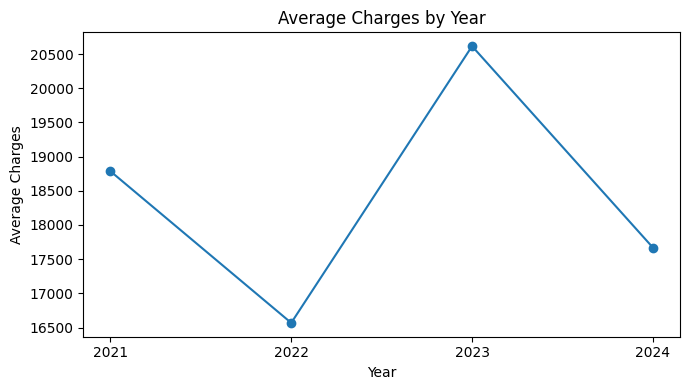

,source_year,row_count,avg_charges
0,2021,1530,18786.55
1,2022,1362,16568.15
2,2023,1547,20615.44
3,2024,1721,17669.92


In [30]:
df_year = con.execute("""
SELECT
    source_year,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_profile_view
WHERE charges_num IS NOT NULL
  AND charges_num >= 0
GROUP BY source_year
ORDER BY source_year;
""").df()

plt.figure(figsize=(7,4))
plt.plot(df_year["source_year"].astype(str), df_year["avg_charges"], marker="o")
plt.title("Average Charges by Year")
plt.xlabel("Year")
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

df_year

## Cell 29 — Charges by region after standardization

### What are we doing?
We analyze average charges by cleaned region.

### Why?
Region is now an evolved domain with new valid values.

### DW value
This supports a region dimension in Gold.


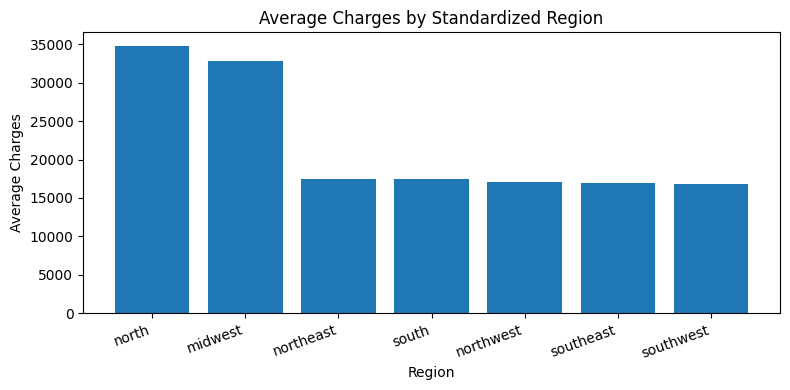

,region,row_count,avg_charges
0,north,215,34820.56
1,midwest,284,32840.97
2,northeast,1177,17515.30
3,south,392,17427.45
4,northwest,1272,17020.21
5,southeast,1476,16989.79
6,southwest,1173,16814.95


In [31]:
df_region = con.execute("""
SELECT
    region_standardized AS region,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_profile_view
WHERE charges_num IS NOT NULL
  AND charges_num >= 0
  AND region_standardized IN (
    'northeast','northwest','southeast','southwest',
    'midwest','north','south'
  )
GROUP BY region_standardized
ORDER BY avg_charges DESC;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_region["region"], df_region["avg_charges"])
plt.title("Average Charges by Standardized Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_region

## Cell 30 — Create enriched analytical view

### What are we doing?
We derive age groups and BMI groups for EDA.

### Why?
Business users prefer categories over raw continuous variables.

### DW value
These derived fields often become Gold reporting dimensions.


In [32]:
con.execute("""
CREATE OR REPLACE VIEW silver.insurance_eda_enriched AS
SELECT
    *,
    CASE
        WHEN age_num < 20 THEN 'under_20'
        WHEN age_num BETWEEN 20 AND 29 THEN '20s'
        WHEN age_num BETWEEN 30 AND 39 THEN '30s'
        WHEN age_num BETWEEN 40 AND 49 THEN '40s'
        WHEN age_num BETWEEN 50 AND 59 THEN '50s'
        WHEN age_num BETWEEN 60 AND 69 THEN '60s'
        ELSE '70_plus'
    END AS age_group,
    CASE
        WHEN bmi_num < 18.5 THEN 'underweight'
        WHEN bmi_num < 25 THEN 'normal'
        WHEN bmi_num < 30 THEN 'overweight'
        ELSE 'obese'
    END AS bmi_group
FROM silver.insurance_profile_view
WHERE age_num BETWEEN 0 AND 120
  AND bmi_num BETWEEN 10 AND 60
  AND children_num BETWEEN 0 AND 10
  AND charges_num >= 0
  AND gender_clean IN ('male', 'female')
  AND smoker_clean IN ('yes', 'no')
  AND region_standardized IN (
    'northeast','northwest','southeast','southwest',
    'midwest','north','south'
  );
""")

con.execute("""
SELECT *
FROM silver.insurance_eda_enriched
LIMIT 10;
""").df()

,source_year,source_file,raw_row_id,age_raw,age_num,gender_clean,bmi_raw,bmi_num,children_raw,children_num,smoker_clean,region_raw,region_trimmed,region_standardized,charges_raw,charges_num,age_group,bmi_group
0,2021,data_messy/insurance.2021.messy.csv,1,42.0,42,female,40.17,40.17,4.0,4,no,northwest,northwest,northwest,18902.47,18902.47,40s,obese
1,2021,data_messy/insurance.2021.messy.csv,2,57.0,57,female,44.85,44.85,1.0,1,no,northwest,northwest,northwest,20917.45,20917.45,50s,obese
2,2021,data_messy/insurance.2021.messy.csv,3,49.0,49,female,36.38,36.38,0.0,0,no,northeast,northeast,northeast,18021.33,18021.33,40s,obese
3,2021,data_messy/insurance.2021.messy.csv,4,47.0,47,male,31.11,31.11,0.0,0,no,southwest,southwest,southwest,8580.46,8580.46,40s,obese
4,2021,data_messy/insurance.2021.messy.csv,5,61.0,61,female,29.28,29.28,1.0,1,no,southeast,southeast,southeast,25497.6,25497.60,60s,overweight
5,2021,data_messy/insurance.2021.messy.csv,6,57.0,57,male,35.91,35.91,0.0,0,yes,north,north,north,34998.76,34998.76,50s,obese
6,2021,data_messy/insurance.2021.messy.csv,7,44.0,44,female,31.78,31.78,4.0,4,no,northwest,northwest,northwest,15025.69,15025.69,40s,obese
7,2021,data_messy/insurance.2021.messy.csv,9,49.0,49,male,15.5,15.50,2.0,2,no,northwest,northwest,northwest,13653.04,13653.04,40s,underweight
8,2021,data_messy/insurance.2021.messy.csv,10,33.0,33,female,33.76,33.76,2.0,2,no,southwest,southwest,southwest,7415.0,7415.00,30s,obese
9,2021,data_messy/insurance.2021.messy.csv,12,33.0,33,female,19.99,19.99,1.0,1,no,southwest,southwest,southwest,5883.52,5883.52,30s,normal


## Cell 31 — Average charges by age group

### What are we doing?
We compare charges by age group.

### Why?
Age is usually an important insurance cost factor.

### DW value
Age group should likely be modeled as a Gold reporting attribute.


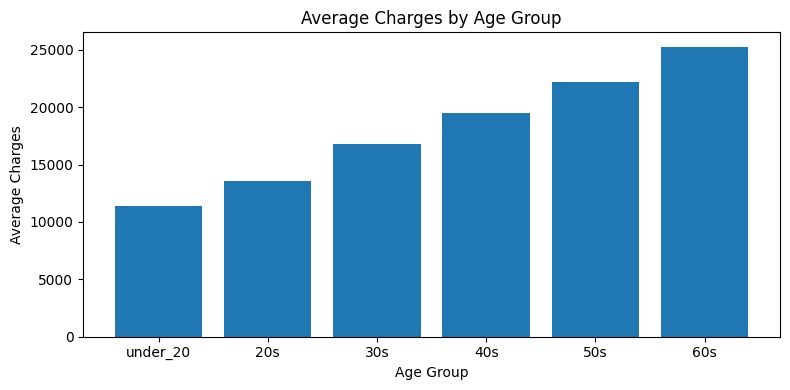

,age_group,row_count,avg_charges
0,under_20,246,11406.91
1,20s,1053,13547.31
2,30s,1028,16782.37
3,40s,1093,19492.65
4,50s,1057,22228.67
5,60s,563,25267.08


In [33]:
df_age_group = con.execute("""
SELECT
    age_group,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_eda_enriched
GROUP BY age_group
ORDER BY
    CASE age_group
        WHEN 'under_20' THEN 1
        WHEN '20s' THEN 2
        WHEN '30s' THEN 3
        WHEN '40s' THEN 4
        WHEN '50s' THEN 5
        WHEN '60s' THEN 6
        ELSE 7
    END;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_age_group["age_group"], df_age_group["avg_charges"])
plt.title("Average Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

df_age_group

## Cell 32 — Average charges by BMI group

### What are we doing?
We compare charges by BMI category.

### Why?
BMI is a health-risk indicator.

### DW value
BMI group is useful for Gold-level segmentation.


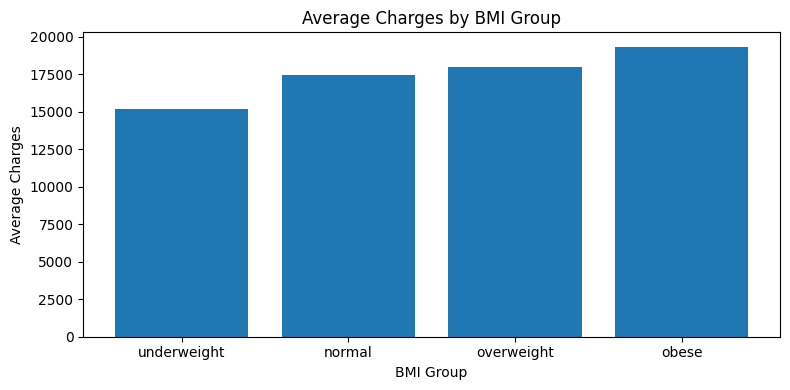

,bmi_group,row_count,avg_charges
0,underweight,138,15212.27
1,normal,839,17450.78
2,overweight,1457,18010.98
3,obese,2606,19327.60


In [34]:
df_bmi_group = con.execute("""
SELECT
    bmi_group,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_eda_enriched
GROUP BY bmi_group
ORDER BY
    CASE bmi_group
        WHEN 'underweight' THEN 1
        WHEN 'normal' THEN 2
        WHEN 'overweight' THEN 3
        ELSE 4
    END;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_bmi_group["bmi_group"], df_bmi_group["avg_charges"])
plt.title("Average Charges by BMI Group")
plt.xlabel("BMI Group")
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

df_bmi_group

## Cell 33 — Smoker + BMI interaction

### What are we doing?
We compare average charges by BMI group and smoker status.

### Why?
Risk factors often interact.

### DW value
This supports multi-dimensional Gold analysis.


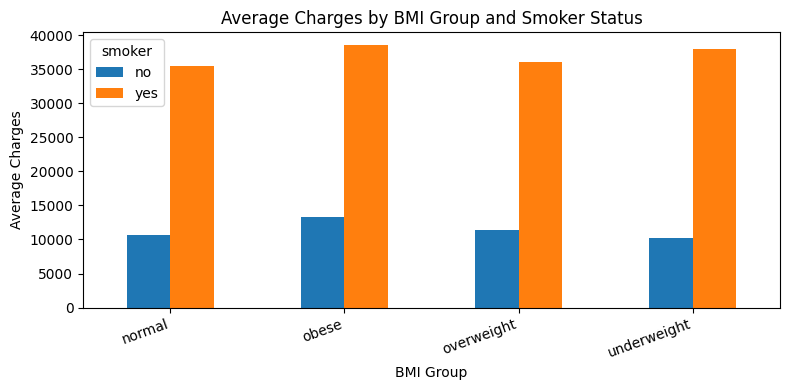

,bmi_group,smoker,row_count,avg_charges
0,normal,no,610,10680.15
1,normal,yes,229,35486.07
2,obese,no,1984,13323.73
3,obese,yes,622,38478.21
4,overweight,no,1065,11397.35
5,overweight,yes,392,35979.13
6,underweight,no,113,10180.93
7,underweight,yes,25,37953.94


In [35]:
df_bmi_smoker = con.execute("""
SELECT
    bmi_group,
    smoker_clean AS smoker,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_eda_enriched
GROUP BY bmi_group, smoker_clean
ORDER BY bmi_group, smoker_clean;
""").df()

pivot = df_bmi_smoker.pivot(index="bmi_group", columns="smoker", values="avg_charges")

pivot.plot(kind="bar", figsize=(8,4))
plt.title("Average Charges by BMI Group and Smoker Status")
plt.xlabel("BMI Group")
plt.ylabel("Average Charges")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_bmi_smoker

## Cell 34 — Region + smoker interaction

### What are we doing?
We compare charges by region and smoker status.

### Why?
This combines geography and risk behavior.

### DW value
This helps identify high-cost segments.


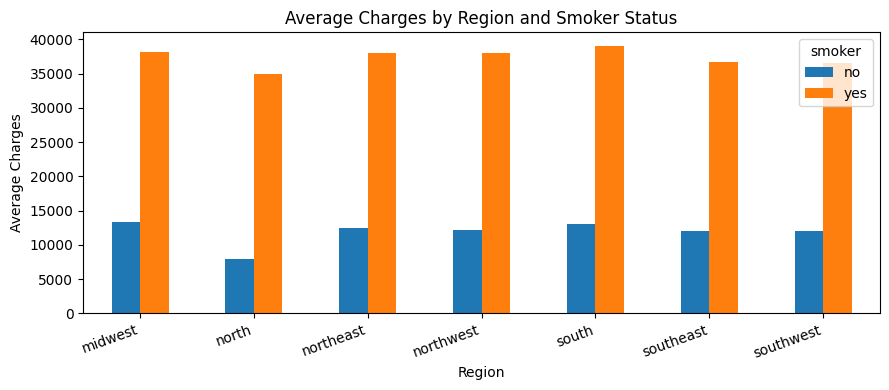

,region,smoker,row_count,avg_charges
0,midwest,no,47,13332.29
1,midwest,yes,187,38103.81
2,north,no,1,7943.70
3,north,yes,188,34950.91
4,northeast,no,788,12495.03
5,northeast,yes,192,37965.99
6,northwest,no,879,12172.04
7,northwest,yes,214,38074.03
8,south,no,262,13070.31
9,south,yes,55,39071.56


In [36]:
df_region_smoker = con.execute("""
SELECT
    region_standardized AS region,
    smoker_clean AS smoker,
    COUNT(*) AS row_count,
    ROUND(AVG(charges_num), 2) AS avg_charges
FROM silver.insurance_eda_enriched
GROUP BY region_standardized, smoker_clean
ORDER BY region_standardized, smoker_clean;
""").df()

pivot = df_region_smoker.pivot(index="region", columns="smoker", values="avg_charges")

pivot.plot(kind="bar", figsize=(9,4))
plt.title("Average Charges by Region and Smoker Status")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_region_smoker

## Cell 35 — Percentile analysis

### What are we doing?
We compute percentiles for charges.

### Why?
Averages can be misleading when data is skewed.

### DW value
Percentiles can become Gold KPIs for more robust reporting.


In [37]:
con.execute("""
SELECT
    ROUND(quantile_cont(charges_num, 0.25), 2) AS p25_charges,
    ROUND(quantile_cont(charges_num, 0.50), 2) AS median_charges,
    ROUND(quantile_cont(charges_num, 0.75), 2) AS p75_charges,
    ROUND(quantile_cont(charges_num, 0.90), 2) AS p90_charges,
    ROUND(quantile_cont(charges_num, 0.95), 2) AS p95_charges,
    ROUND(quantile_cont(charges_num, 0.99), 2) AS p99_charges
FROM silver.insurance_eda_enriched;
""").df()

,p25_charges,median_charges,p75_charges,p90_charges,p95_charges,p99_charges
0,8937.46,14798.71,26288.8,39235.7,43812.66,51504.59


---
# Part 7 — EDA Findings → Silver Actions
---

## Cell 36 — EDA finding to Silver action map

### What are we doing?
We summarize what the EDA found and what the Silver layer should do.

### Why?
EDA is only valuable if it leads to better data engineering.

### DW value
This becomes the design contract for the Silver layer.


In [38]:
eda_to_silver = pd.DataFrame([
    ["Invalid age", "age_num is NULL, < 0, or > 120", "Reject row"],
    ["Invalid BMI", "bmi_num is NULL, < 10, or > 60", "Reject row"],
    ["Invalid charges", "charges_num is NULL or < 0", "Reject row"],
    ["Invalid children", "children_num is NULL, < 0, or > 10", "Reject row"],
    ["Messy region formatting", "north east, SOUTHWEST, extra spaces", "Standardize"],
    ["Invalid region", "mars or unknown non-business value", "Reject row"],
    ["Invalid gender/smoker", "outside approved domain", "Reject or standardize if mapped"],
    ["Duplicates", "same full record appears more than once", "Deduplicate"],
    ["Semantic anomaly", "smoker=yes but charges unusually low", "Flag, do not necessarily reject"],
], columns=["EDA Finding", "Detection Logic", "Silver Action"])

eda_to_silver

,EDA Finding,Detection Logic,Silver Action
0,Invalid age,"age_num is NULL, < 0, or > 120",Reject row
1,Invalid BMI,"bmi_num is NULL, < 10, or > 60",Reject row
2,Invalid charges,charges_num is NULL or < 0,Reject row
3,Invalid children,"children_num is NULL, < 0, or > 10",Reject row
4,Messy region formatting,"north east, SOUTHWEST, extra spaces",Standardize
5,Invalid region,mars or unknown non-business value,Reject row
6,Invalid gender/smoker,outside approved domain,Reject or standardize if mapped
7,Duplicates,same full record appears more than once,Deduplicate
8,Semantic anomaly,smoker=yes but charges unusually low,"Flag, do not necessarily reject"


## Cell 37 — Recommended Silver clean logic

### What are we doing?
We show the core SQL pattern for the future Silver table.

### Why?
This connects EDA directly to implementation.

### DW value
Students can see how business rules become SQL.


In [39]:
silver_pattern = r'''
CREATE OR REPLACE TABLE silver.insurance_clean AS
SELECT DISTINCT
    source_year,
    age_num AS age,
    gender_clean AS gender,
    bmi_num AS bmi,
    children_num AS children,
    smoker_clean AS smoker,
    region_standardized AS region,
    charges_num AS charges,

    CASE
        WHEN smoker_clean = 'yes' AND charges_num < 500 THEN 1
        ELSE 0
    END AS semantic_low_charge_smoker_flag

FROM silver.insurance_profile_view
WHERE age_num BETWEEN 0 AND 120
  AND bmi_num BETWEEN 10 AND 60
  AND children_num BETWEEN 0 AND 10
  AND charges_num >= 0
  AND gender_clean IN ('male', 'female')
  AND smoker_clean IN ('yes', 'no')
  AND region_standardized IN (
      'northeast','northwest','southeast','southwest',
      'central','east','west'
  );
'''

print(silver_pattern)


CREATE OR REPLACE TABLE silver.insurance_clean AS
SELECT DISTINCT
    source_year,
    age_num AS age,
    gender_clean AS gender,
    bmi_num AS bmi,
    children_num AS children,
    smoker_clean AS smoker,
    region_standardized AS region,
    charges_num AS charges,

    CASE
        WHEN smoker_clean = 'yes' AND charges_num < 500 THEN 1
        ELSE 0
    END AS semantic_low_charge_smoker_flag

FROM silver.insurance_profile_view
WHERE age_num BETWEEN 0 AND 120
  AND bmi_num BETWEEN 10 AND 60
  AND children_num BETWEEN 0 AND 10
  AND charges_num >= 0
  AND gender_clean IN ('male', 'female')
  AND smoker_clean IN ('yes', 'no')
  AND region_standardized IN (
      'northeast','northwest','southeast','southwest',
      'central','east','west'
  );



---
# Part 8 — Final Teaching Summary
---

# Final Summary

## What did we learn?

This EDA found several classes of data quality issues:

| Issue Type | Example | Silver Strategy |
|---|---|---|
| Invalid numeric values | age = -5, bmi = 200 | reject |
| Invalid financial values | charges = -1000 | reject |
| Invalid domain values | smoker = maybe, region = mars | reject |
| Formatting issues | north east, SOUTHWEST | standardize |
| Duplicate records | repeated full records | deduplicate |
| Semantic anomalies | smoker=yes but charges very low | flag |

---

## Key DW lesson

EDA is not separate from data warehousing.

EDA tells us:

1. what is wrong in Bronze  
2. what rules are needed in Silver  
3. what dimensions and KPIs are safe for Gold  

---

## Final message for students

> **Do not build Gold dashboards until Bronze has been explored and Silver rules are justified.**
